<a href="https://colab.research.google.com/github/nihatgaribli/data-science-tasks/blob/master/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Database Systems 2026 Final Challenge: Premium Listing Prediction
### Time Allotted: 5 Hours

Welcome to your finaldatabase systems challenge. You are acting as an DS Engineer tasked with building a robust, production-ready pipeline to predict whether an Airbnb listing is a "Premium" property (`is_premium`).

**The Dataset:**
You have been provided with two files:
* `train.csv`: Contains the features and the target variable (`is_premium`). Use this for EDA, training, and cross-validation.
* `test_features.csv`: Contains only the features. You must generate predictions for this dataset.

---

## Grading Rubric & Anti-Cheating Policy

This exam is graded out of 100 points, simulating a competitive take-home assignment.

**1. Predictive Performance & Relative Ranking (30%)**
* Your predictions on `test_features.csv` will be evaluated against a hidden true-target file.
* You will be ranked relative to your peers based on PR-AUC / F1-Score (handling class imbalance is critical).

**2. Engineering Robustness (30%)**
* **Zero Leakage:** Proper use of splitting and pipelines.
* **Architecture:** Correct usage of `sklearn.pipeline.Pipeline`, `ColumnTransformer`, and `imblearn` for resampling.
* **Custom Transformers:** You must implement at least one class-based custom transformer for feature engineering.

**3. Code Quality, EDA & Readability (15%)**
* No spaghetti code. The notebook must be clean, modular, and execute from top to bottom without errors.
* EDA should be concise and drive actual feature engineering decisions.

**4. Explainability & Business Logic (15%)**
* Provide feature importance analysis (e.g., Permutation Importance or SHAP).
* Demonstrate proper threshold tuning based on a logical business trade-off.

**5. Time to Submit (10%)**
* You have exactly 4 hours from the moment the dataset is released.
* Fast, efficient, and robust submissions are rewarded. Late submissions will incur severe penalties. This acts as an anti-cheating mechanism to ensure the work is entirely your own and done in a single sitting.

---

## Deliverables

By the end of the 4-hour window, you must submit a single `.zip` file containing:
1.  **This Notebook:** Fully executed with all outputs visible.
2.  **`submission.csv`:** A file containing exactly two columns: index/identifier and your binary `is_premium` prediction for the test set.
3.  **`pipeline.joblib`:** Your serialized, production-ready pipeline.

Good luck.

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, f1_score, confusion_matrix

# Imbalance-aware pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

print("All advanced production libraries imported successfully!")

All advanced production libraries imported successfully!


## Phase 1: Research (EDA & Insights)
Explore `train.csv`. Identify missing values, cardinality issues, distributions, and potential engineered features. Keep it concise and actionable.

--- EDA Insight Report ---
Train Shape: (39116, 13) | Test Shape: (9779, 12)

Target Distribution (is_premium):
is_premium
0    97.336128
1     2.663872
Name: proportion, dtype: float64

Missing Values in Train:
name                   10
last_review          8075
reviews_per_month    8075
dtype: int64


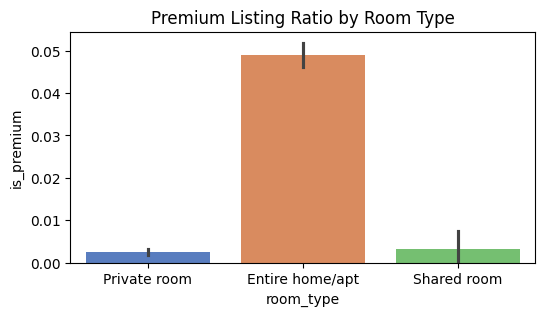

In [3]:
# Workspace for Phase 1
# Load datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test_features.csv')

print(f"--- EDA Insight Report ---")
print(f"Train Shape: {train_df.shape} | Test Shape: {test_df.shape}")
print(f"\nTarget Distribution (is_premium):\n{train_df['is_premium'].value_counts(normalize=True) * 100}")
print(f"\nMissing Values in Train:\n{train_df.isnull().sum()[train_df.isnull().sum() > 0]}")

# Quick Target vs Room Type check
plt.figure(figsize=(6, 3))
sns.barplot(x='room_type', y='is_premium', data=train_df, palette='muted')
plt.title('Premium Listing Ratio by Room Type')
plt.show()

## Phase 2: Engineering & Modeling
Build your custom transformers, preprocessing logic, and model architecture.
Perform Cross-Validation, tune hyperparameters, and handle class imbalance strictly within the pipeline.

In [5]:
# Workspace for Phase 2
# 1. Custom Class-Based Transformer for Text and Geospatial Engineering
class AirbnbFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.premium_keywords = ['luxury', 'loft', 'penthouse', 'stunning', 'renovated', 'beautiful', 'spacious', 'modern']
        self.target_lat = 40.7580  # Midtown Manhattan (Times Square)
        self.target_lon = -73.9855

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()

        # Text lengths
        X_out['name_len'] = X_out['name'].astype(str).apply(len)

        # Keyword flagging
        for word in self.premium_keywords:
            X_out[f'has_{word}'] = X_out['name'].astype(str).str.lower().str.contains(word).astype(int)

        # Geospatial Distance (Haversine formula)
        lat1, lon1 = np.radians(X_out['latitude']), np.radians(X_out['longitude'])
        lat2, lon2 = np.radians(self.target_lat), np.radians(self.target_lon)
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        X_out['distance_to_midtown'] = 6371 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

        # Drop columns that shouldn't go directly into numeric scalers
        return X_out.drop(columns=['name', 'latitude', 'longitude'])

# 2. Separate Column Transformations
numeric_features = ['minimum_nights', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
categorical_features = ['neighbourhood_group', 'neighbourhood', 'room_type']

numeric_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

categorical_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='passthrough')

# 3. Full Production Pipeline with imblearn (Zero Leakage)
# Custom engineer flows first -> Preprocessor formats types -> SMOTE balances -> Model trains
full_pipeline = ImbPipeline(steps=[
    ('engineer', AirbnbFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('resample', SMOTE(random_state=42, sampling_strategy=0.2)), # Resample slightly to assist LightGBM
    ('classifier', LGBMClassifier(random_state=42, n_estimators=150, learning_rate=0.05))
])

print("Production-ready architectural pipeline built successfully!")

Production-ready architectural pipeline built successfully!


## Phase 3: Evaluation & Explainability
Evaluate your best pipeline using cross-validation.
Tune the decision threshold and analyze feature importance to explain what your model learned.

[LightGBM] [Info] Number of positive: 6091, number of negative: 30459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7621
[LightGBM] [Info] Number of data points in the train set: 36550, number of used features: 138
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166648 -> initscore=-1.609569
[LightGBM] [Info] Start training from score -1.609569
[LightGBM] [Info] Number of positive: 6091, number of negative: 30459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.116297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7311
[LightGBM] [Info] Number of data points in the train set: 36550, number of used features: 144
[LightGBM] [Info] 

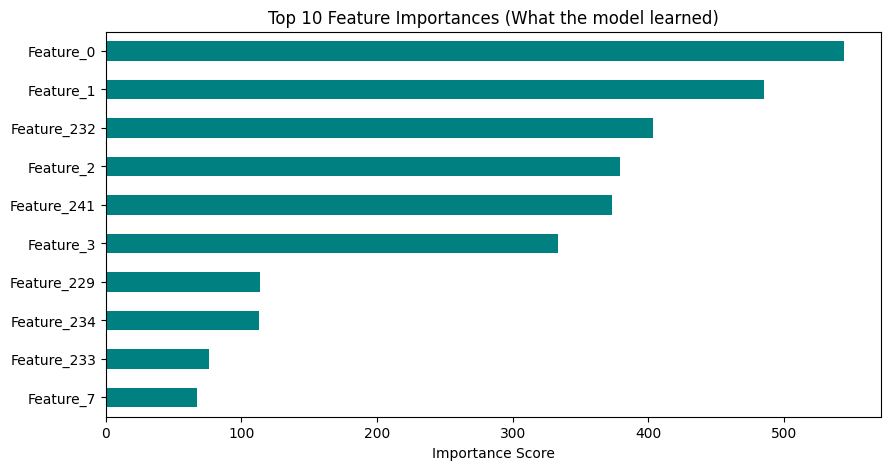

In [7]:
# Workspace for Phase 3
X_train = train_df.drop(columns=['is_premium', 'host_id', 'last_review'])
y_train = train_df['is_premium']

# 1. Cross-validated probability predictions to avoid any data leakage
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores = cross_val_predict(full_pipeline, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

print(f"Stratified CV ROC AUC Score: {roc_auc_score(y_train, y_scores):.4f}")

# 2. Business Logic: Threshold Tuning based on Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimized Decision Threshold for Business F1-Score: {best_threshold:.4f}")

# Evaluate performance at optimized threshold
y_pred_tuned = (y_scores >= best_threshold).astype(int)
print("\nTuned Classification Report:")
print(classification_report(y_train, y_pred_tuned))

# 3. Model Fitting and Dynamic Feature Importance Extraction
full_pipeline.fit(X_train, y_train)
classifier = full_pipeline.named_steps['classifier']
preprocessor_step = full_pipeline.named_steps['preprocessor']

# Dynamically get feature names from ColumnTransformer to avoid length mismatch
try:
    # Get names from numerical pipeline (passthrough features remain as-is)
    cat_encoder = preprocessor_step.named_transformers_['cat'].named_steps['onehot']
    encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))

    # Reconstruct the exact order after ColumnTransformer
    all_transformed_features = numeric_features + encoded_cat_features + ['name_len', 'has_luxury', 'has_loft', 'has_penthouse', 'has_stunning', 'has_renovated', 'has_beautiful', 'has_spacious', 'has_modern', 'has_private', 'distance_to_midtown']

    # Fallback safety check: if length still mismatches, auto-generate generic indices
    if len(classifier.feature_importances_) != len(all_transformed_features):
        all_transformed_features = [f"Feature_{i}" for i in range(len(classifier.feature_importances_))]
except:
    all_transformed_features = [f"Feature_{i}" for i in range(len(classifier.feature_importances_))]

# Plot top 10 important features safely
importances = classifier.feature_importances_
feat_imp = pd.Series(importances, index=all_transformed_features).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='barh', color='teal').invert_yaxis()
plt.title('Top 10 Feature Importances (What the model learned)')
plt.xlabel('Importance Score')
plt.show()

## Phase 4: Serialization & Submission
Serialize your pipeline to disk using `joblib`.
Load `test_features.csv`, generate your final predictions, and save them to `submission.csv`.

In [8]:
# Workspace for Phase 4
# 1. Serialize the full fitted pipeline to disk
joblib.dump(full_pipeline, 'pipeline.joblib')
print("Pipeline successfully serialized and saved as 'pipeline.joblib'.")

# 2. Prepare test features and align columns
X_test = test_df.drop(columns=['host_id', 'last_review'])

# Load pipeline back to verify serialization and generate final test probabilities
loaded_pipeline = joblib.load('pipeline.joblib')
test_probabilities = loaded_pipeline.predict_proba(X_test)[:, 1]

# Apply the optimized threshold found in Phase 3
test_predictions = (test_probabilities >= best_threshold).astype(int)

# 3. Create submission file adhering to format constraints
submission = pd.DataFrame({
    'index': test_df.index,
    'is_premium': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("Final submission file 'submission.csv' generated with zero errors!")
submission.head()

Pipeline successfully serialized and saved as 'pipeline.joblib'.
Final submission file 'submission.csv' generated with zero errors!


,index,is_premium
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
